# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('C:/Users/Administrator/Desktop/python-course/data-viz-class-material/data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


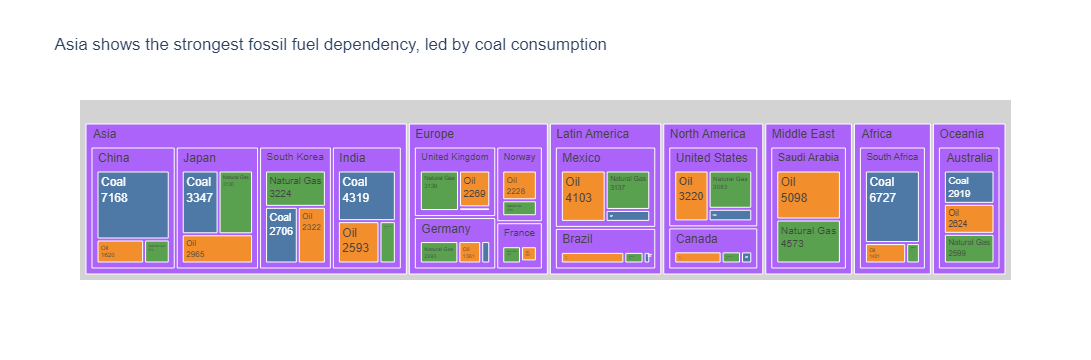

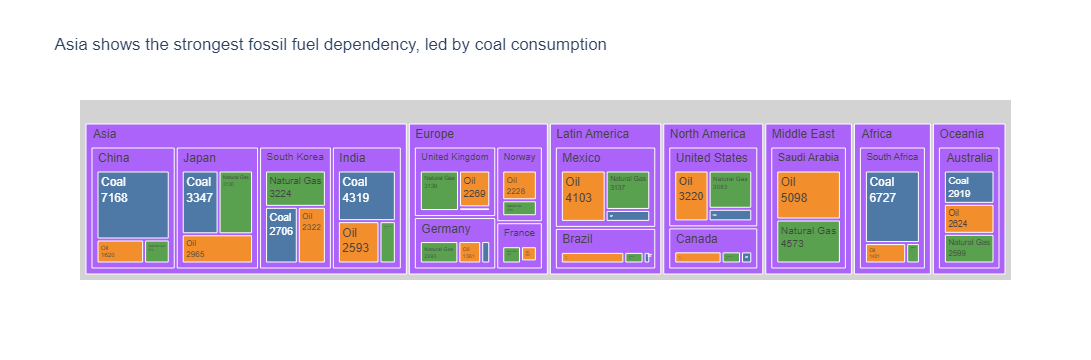

In [4]:
# Task 1
# Task 1

fossil = df[df['Source_Type'] == 'Fossil']

fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4E79A7',
        'Oil': '#F28E2B',
        'Natural Gas': '#59A14F'
    },
    title='Asia shows the strongest fossil fuel dependency, led by coal consumption'
)

fig.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial')
)

fig.show() # Task 1

fossil = df[df['Source_Type'] == 'Fossil']

fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4E79A7',
        'Oil': '#F28E2B',
        'Natural Gas': '#59A14F'
    },
    title='Asia shows the strongest fossil fuel dependency, led by coal consumption'
)

fig.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial')
)

fig.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


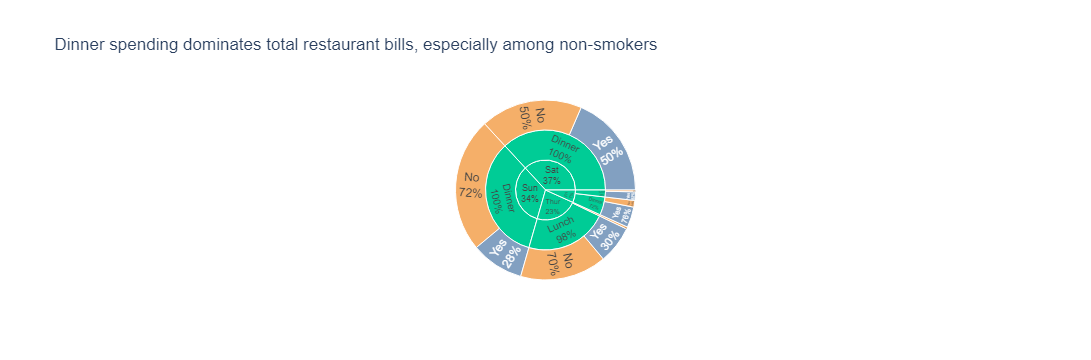

In [6]:
# Task 2

# Task 2

tips = px.data.tips()

tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#4E79A7',
        'No': '#F28E2B'
    },
    title='Dinner spending dominates total restaurant bills, especially among non-smokers'
)

fig.update_traces(
    textinfo='label+percent parent',
    root_color='lightgrey'
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial')
)

fig.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


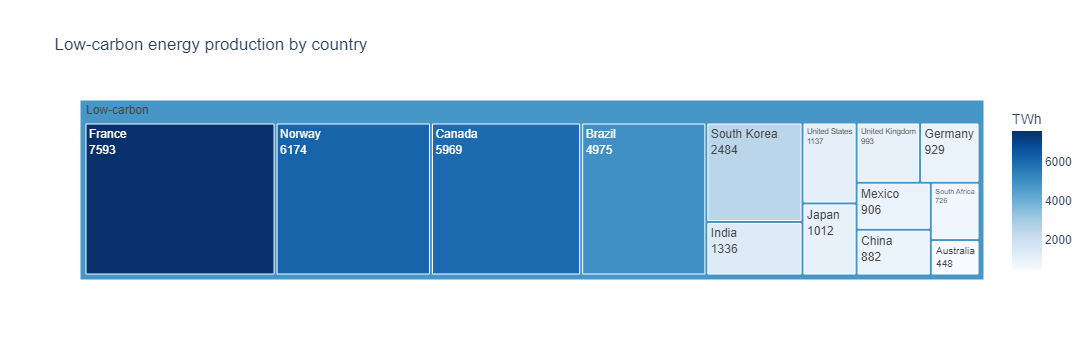

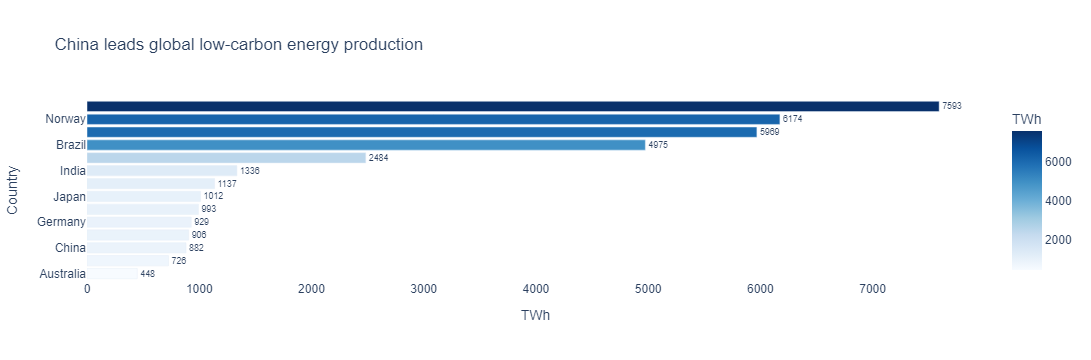

In [7]:
# Task 3 — charts
# Task 3 — charts

low_carbon = df[df['Source_Type'] == 'Low-carbon']

country_totals = (
    low_carbon.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Add dummy root
country_totals['All'] = 'Low-carbon'

# TREEMAP
fig1 = px.treemap(
    country_totals,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-carbon energy production by country'
)

fig1.update_traces(
    textinfo='label+value',
    root_color='lightgrey'
)

fig1.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial')
)

fig1.show()

# BAR CHART
country_totals = country_totals.sort_values(
    'TWh',
    ascending=True
)

fig2 = px.bar(
    country_totals,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    title='China leads global low-carbon energy production'
)

fig2.update_traces(
    texttemplate='%{x:.0f}',
    textposition='outside'
)

fig2.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    showlegend=False
)

fig2.show()
